In [3]:
import pandas as pd
import numpy as np
import sklearn
from datasets import load_dataset
dataset=load_dataset("stanfordnlp/imdb")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:

train_df=pd.DataFrame(dataset["train"])
test_df=pd.DataFrame(dataset["test"])
print("Train data size:" , len(train_df))
print("Test data size:", len(test_df));
print(train_df["text"][0][:300])
print(test_df["text"][0])


Train data size: 25000
Test data size: 25000
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi TV. It's not. It's clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself se

Negative reviews:  12500
Positive reviews:  12500


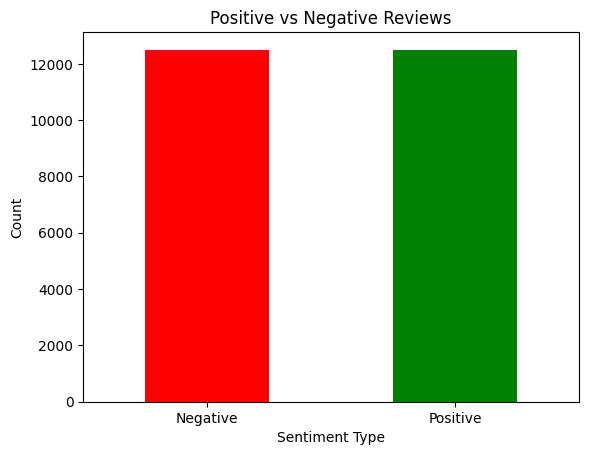

In [5]:
#check the data balance 
import matplotlib.pyplot as plt 
counts=train_df["label"].value_counts()
print("Negative reviews: ",counts[0])
print("Positive reviews: ",counts[1])
counts.plot(kind="bar", color=["red","green"])
plt.title("Positive vs Negative Reviews")
plt.xticks([0,1],["Negative","Positive"],rotation=0)
plt.xlabel("Sentiment Type")
plt.ylabel("Count")
plt.show()

In [6]:
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^A-Za-z\s]", "", text)
    text = text.lower()
    tokens = text.split()
    filtered_tokens = []
    for w in tokens:
        if w not in stop_words:
            filtered_tokens.append(w)
    tokens = filtered_tokens
    return " ".join(tokens)

train_df["filtered_text"] = train_df["text"].apply(clean_text)
test_df["filtered_text"] = test_df["text"].apply(clean_text)
print("Done!")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Deeptie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Done!


In [7]:
train_df.to_csv("train_clean.csv", index=False)
test_df.to_csv("test_clean.csv", index=False)
print("Saved!")

Saved!
